In [17]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [20]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [21]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [23]:
df.shape

(100, 3)

In [24]:
df.head()

,feature1,feature2,target
0,0.422334,-0.999728,-93.774695
1,-0.775405,-0.480931,1.218957
2,-1.619104,0.539843,32.285579
3,0.229612,1.138901,65.600885
4,0.190591,0.944127,79.539504


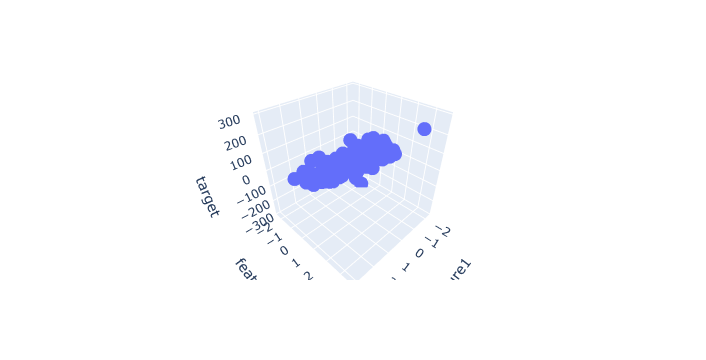

In [25]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
lr = LinearRegression()

In [29]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = lr.predict(X_test)

In [31]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 34.95706571231948
MSE 1951.3301638800367
R2 score 0.8335289339726075


In [34]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)
z = z_final

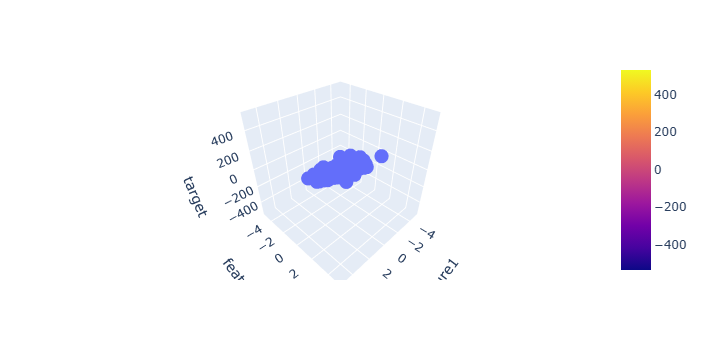

In [35]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.add_trace(go.Surface(x = x, y = y, z =z ))
fig.show()

In [36]:
lr.coef_

array([28.0280939 , 78.50969156])

In [37]:
lr.intercept_

np.float64(-2.560602898665163)